# Wild Apple Forest Local Python Workflow

Phase-B scaffold for the Ili 2021 wild apple forest workflow.

Current scope:
- migrate the core logic of `ili_demo3_debug.js` into local GEE Python
- switch the image source to Sentinel-2 + Sentinel-1 monthly composites
- keep the structure aligned with the three project documents in this repo
- provide a first runnable baseline for sample extraction and local RF modeling

Later steps will fill in:
- sample cleaning rules
- cubic time-series fitting
- Jeffries-Matusita feature screening
- SHAP interpretation
- geemap.ml model back-write to GEE
- stricter post-processing and area reporting
        


In [1]:
from pathlib import Path
import warnings

import ee
import geemap
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("outputs") / "wildapple_localrun_2021"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "gee_project": "kindle-400911",
    "year": 2021,
    "start_month": 3,
    "end_month": 10,
    "scale": 20,
    "random_seed": 42,
    "wildapple_asset": "projects/kindle-400911/assets/wildapple_sample",
    "worldcover_points_per_class": 150,
    "enable_wildapple_buffer": True,
    "wildapple_buffer_m": 20,
    "rect_sample_scale": 30,
    "wildapple_rect_group_id": "wildapple_rect_01",
    "wildapple_rect_corners": [
        [82.77484146, 43.20874077],
        [82.77116641, 43.2112944],
        [82.77223955, 43.21193612],
        [82.7756369, 43.20940169],
    ],
    "adm0_name": "China",
    "adm1_name": "Xinjiang Uygur Zizhiqu",
    "adm2_name": "Ili Kazakh",
    "valley_elevation_threshold_m": 1800,
    "valley_slope_threshold_deg": 12,
    "s1_orbit_mode": "asc_only",
    "s1_speckle_radius_pixels": 1,
    "postprocess_min_patch_pixels": 150,
}

CLASS_INFO = {
    1: "Wild Apple Forest",
    2: "Other Forest",
    3: "Cropland",
    4: "Grassland/Shrub",
    5: "Urban/Bare",
    6: "Water/Snow/Ice",
}

MONTHS = list(range(CONFIG["start_month"], CONFIG["end_month"] + 1))
PROJ = None
OPTICAL_SERIES_PREFIXES = ["NDVI", "EVI", "NDMI", "LSWI"]
S1_PASS_LABELS = {"ASCENDING": "ASC", "DESCENDING": "DESC"}
SAR_BASE_PREFIXES = ["VV_db", "VH_db", "VV_VH_ratio", "VV_minus_VH_db"]


def get_active_s1_pass_items():
    mode = CONFIG["s1_orbit_mode"]
    if mode == "asc_only":
        return [("ASCENDING", "ASC")]
    if mode == "desc_only":
        return [("DESCENDING", "DESC")]
    return list(S1_PASS_LABELS.items())


def get_sar_series_prefixes():
    if CONFIG["s1_orbit_mode"] == "separate":
        return [f"{base}_{pass_label}" for _, pass_label in get_active_s1_pass_items() for base in SAR_BASE_PREFIXES]
    return list(SAR_BASE_PREFIXES)


SAR_SERIES_PREFIXES = get_sar_series_prefixes()
SUMMARY_PREFIXES = OPTICAL_SERIES_PREFIXES + SAR_SERIES_PREFIXES

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Months: {MONTHS}")
print(f"S1 orbit mode: {CONFIG['s1_orbit_mode']}")
print(f"S1 speckle radius (pixels): {CONFIG['s1_speckle_radius_pixels']}")
        


Output directory: D:\CODE\VS__Project\GEE\WildAppleForest_GEE\outputs\wildapple_localrun_2021
Months: [3, 4, 5, 6, 7, 8, 9, 10]
S1 orbit mode: asc_only
S1 speckle radius (pixels): 1


In [2]:
ee.Initialize(project=CONFIG["gee_project"])
PROJ = ee.Projection("EPSG:3857").atScale(CONFIG["scale"])
print("Earth Engine initialized.")
        


Earth Engine initialized.


## 1. ROI and core utilities


In [3]:
def get_ili_roi():
    admin = (
        ee.FeatureCollection("FAO/GAUL/2015/level2")
        .filter(ee.Filter.eq("ADM0_NAME", CONFIG["adm0_name"]))
        .filter(ee.Filter.eq("ADM1_NAME", CONFIG["adm1_name"]))
        .filter(ee.Filter.eq("ADM2_NAME", CONFIG["adm2_name"]))
    )
    return admin.geometry()


def month_tag(month):
    return f"M{int(month):02d}"


def month_band_names(prefix):
    return [f"{prefix}_{month_tag(month)}" for month in MONTHS]


def add_string_id(fc, id_field="sample_id", prefix="sample"):
    fc = ee.FeatureCollection(fc)
    size = fc.size()

    def _non_empty(collection):
        collection = ee.FeatureCollection(collection)
        collection_list = collection.toList(collection.size())

        def _mapper(i):
            i = ee.Number(i)
            feature = ee.Feature(collection_list.get(i))
            sample_id = ee.String(prefix).cat("_").cat(i.format("%05d"))
            return feature.set(id_field, sample_id)

        return ee.FeatureCollection(ee.List.sequence(0, collection.size().subtract(1)).map(_mapper))

    return ee.FeatureCollection(ee.Algorithms.If(size.gt(0), _non_empty(fc), fc))


def build_rect_geometry(corners):
    return ee.Geometry.Polygon([corners], None, False)


ROI = get_ili_roi()
print("ROI ready.")

roi_center = ROI.centroid(100).coordinates().getInfo()
roi_geojson = ee.Feature(ROI).getInfo()

Map = folium.Map(location=[roi_center[1], roi_center[0]], zoom_start=7, control_scale=True)
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attr="Google",
    name="Google Satellite",
    overlay=False,
    control=True,
).add_to(Map)
folium.GeoJson(
    data=roi_geojson,
    name="ROI",
    style_function=lambda _: {"color": "#ffcc00", "weight": 2, "fillOpacity": 0.0},
).add_to(Map)
folium.LayerControl().add_to(Map)
Map
        


ROI ready.


## 2. Sentinel-2, Sentinel-1, terrain, and monthly feature image


In [4]:
S2_RAW_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]
S2_RENAMED_BANDS = ["blue", "green", "red", "nir", "swir1", "swir2"]
S2_QA_COLLECTION = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")
S2_QA_BAND = "cs_cdf"
S2_CLEAR_THRESHOLD = 0.60


def add_optical_indices(image):
    ndvi = image.normalizedDifference(["nir", "red"]).rename("NDVI")
    evi = image.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {"NIR": image.select("nir"), "RED": image.select("red"), "BLUE": image.select("blue")},
    ).rename("EVI")
    ndmi = image.normalizedDifference(["nir", "swir1"]).rename("NDMI")
    lswi = image.normalizedDifference(["nir", "swir2"]).rename("LSWI")
    ndbi = image.normalizedDifference(["swir1", "nir"]).rename("NDBI")
    bsi = image.expression(
        "((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))",
        {"SWIR": image.select("swir1"), "RED": image.select("red"), "NIR": image.select("nir"), "BLUE": image.select("blue")},
    ).rename("BSI")
    gcvi = image.expression("(NIR / GREEN) - 1", {"NIR": image.select("nir"), "GREEN": image.select("green")}).rename("GCVI")
    return image.addBands([ndvi, evi, ndmi, lswi, ndbi, bsi, gcvi])


def preprocess_s2(image):
    image = image.updateMask(image.select(S2_QA_BAND).gte(S2_CLEAR_THRESHOLD))
    image = image.select(S2_RAW_BANDS).rename(S2_RENAMED_BANDS).multiply(0.0001)
    return add_optical_indices(image).resample("bilinear").reproject(PROJ)


def load_monthly_s2(month):
    start_date = ee.Date.fromYMD(CONFIG["year"], month, 1)
    end_date = start_date.advance(1, "month")
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(ROI)
        .filterDate(start_date, end_date)
        .linkCollection(S2_QA_COLLECTION, [S2_QA_BAND])
        .map(preprocess_s2)
    )
    return collection.median().setDefaultProjection(PROJ).clip(ROI)


def db_to_linear(image):
    return ee.Image.constant(10).pow(image.divide(10))


def linear_to_db(image):
    return image.max(ee.Image.constant(1e-6)).log10().multiply(10)


def apply_s1_speckle_filter(vv_linear, vh_linear):
    radius = CONFIG["s1_speckle_radius_pixels"]
    kernel = ee.Kernel.square(radius=radius, units="pixels", normalize=True)
    vv_filtered = vv_linear.reduceNeighborhood(ee.Reducer.mean(), kernel)
    vh_filtered = vh_linear.reduceNeighborhood(ee.Reducer.mean(), kernel)
    return vv_filtered, vh_filtered


def preprocess_s1(image):
    vv_db_raw = image.select("VV")
    vh_db_raw = image.select("VH")
    vv_linear = db_to_linear(vv_db_raw)
    vh_linear = db_to_linear(vh_db_raw)
    vv_linear, vh_linear = apply_s1_speckle_filter(vv_linear, vh_linear)
    vv_db = linear_to_db(vv_linear).rename("VV_db")
    vh_db = linear_to_db(vh_linear).rename("VH_db")
    ratio = vv_linear.divide(vh_linear.max(ee.Image.constant(1e-6))).rename("VV_VH_ratio")
    diff_db = vv_db.subtract(vh_db).rename("VV_minus_VH_db")
    return ee.Image.cat([vv_db, vh_db, ratio, diff_db]).reproject(PROJ)


def load_monthly_s1_collection(month, orbit_pass=None):
    start_date = ee.Date.fromYMD(CONFIG["year"], month, 1)
    end_date = start_date.advance(1, "month")
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(ROI)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    )
    if orbit_pass is not None:
        collection = collection.filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
    return collection


def empty_s1_feature_image():
    return ee.Image.constant([0, 0, 0, 0]).rename(SAR_BASE_PREFIXES).updateMask(ee.Image.constant(0)).setDefaultProjection(PROJ)


def load_monthly_s1(month, orbit_pass=None):
    collection = load_monthly_s1_collection(month, orbit_pass).map(preprocess_s1)
    composite = ee.Image(ee.Algorithms.If(collection.size().gt(0), collection.median(), empty_s1_feature_image()))
    return composite.setDefaultProjection(PROJ).clip(ROI)


def rename_with_month(image, month):
    suffix = month_tag(month)
    new_names = image.bandNames().map(lambda name: ee.String(name).cat("_").cat(suffix))
    return image.rename(new_names)


def rename_s1_with_pass_and_month(image, pass_label, month):
    suffix = f"{pass_label}_{month_tag(month)}"
    new_names = image.bandNames().map(lambda name: ee.String(name).cat("_").cat(suffix))
    return image.rename(new_names)


def build_monthly_feature_image():
    monthly_images = []
    for month in MONTHS:
        optical = load_monthly_s2(month)
        monthly_images.append(rename_with_month(optical, month))
        if CONFIG["s1_orbit_mode"] == "separate":
            for orbit_pass, pass_label in get_active_s1_pass_items():
                sar = load_monthly_s1(month, orbit_pass)
                monthly_images.append(rename_s1_with_pass_and_month(sar, pass_label, month))
        else:
            orbit_pass = get_active_s1_pass_items()[0][0] if CONFIG["s1_orbit_mode"] in ["asc_only", "desc_only"] else None
            sar = load_monthly_s1(month, orbit_pass)
            monthly_images.append(rename_with_month(sar, month))
    return ee.Image.cat(monthly_images).clip(ROI)


def summary_from_month_stack(image, prefix):
    names = month_band_names(prefix)
    stack = image.select(names)
    stack_mean = stack.reduce(ee.Reducer.mean()).rename(f"{prefix}_mean")
    stack_std = stack.reduce(ee.Reducer.stdDev()).rename(f"{prefix}_std")
    stack_min = stack.reduce(ee.Reducer.min()).rename(f"{prefix}_min")
    stack_max = stack.reduce(ee.Reducer.max()).rename(f"{prefix}_max")
    stack_amp = stack_max.subtract(stack_min).rename(f"{prefix}_amp")

    array_image = stack.toArray()
    peak_index = array_image.arrayArgmax().arrayGet([0])
    peak_month = ee.Image(peak_index).add(CONFIG["start_month"]).rename(f"{prefix}_peak_month")

    first_band = stack.select([0]).rename(f"{prefix}_spring_ref")
    mid_band = stack.select([int(len(MONTHS) / 2)]).rename(f"{prefix}_summer_ref")
    last_band = stack.select([len(MONTHS) - 1]).rename(f"{prefix}_autumn_ref")
    spring_rise = mid_band.subtract(first_band).rename(f"{prefix}_spring_rise")
    autumn_decline = mid_band.subtract(last_band).rename(f"{prefix}_autumn_decline")

    return ee.Image.cat([stack_mean, stack_std, stack_min, stack_max, stack_amp, peak_month, spring_rise, autumn_decline])


def build_summary_image(image):
    return ee.Image.cat([summary_from_month_stack(image, prefix) for prefix in SUMMARY_PREFIXES])


def build_terrain_image():
    dem = ee.Image("USGS/SRTMGL1_003").clip(ROI)
    terrain = ee.Algorithms.Terrain(dem)
    elevation = terrain.select("elevation").rename("elevation")
    slope = terrain.select("slope").rename("slope")
    aspect = terrain.select("aspect").rename("aspect")
    valley_proxy = elevation.lt(CONFIG["valley_elevation_threshold_m"]).And(slope.lt(CONFIG["valley_slope_threshold_deg"]))
    valley_distance = valley_proxy.fastDistanceTransform(128, "pixels", "squared_euclidean").sqrt().multiply(CONFIG["scale"]).rename("dist_to_valley_proxy_m")
    return ee.Image.cat([elevation, slope, aspect, valley_distance])


def build_texture_image(monthly_image):
    ndvi_name = "NDVI_M07" if 7 in MONTHS else f"NDVI_{month_tag(MONTHS[len(MONTHS) // 2])}"
    gray = monthly_image.select(ndvi_name).unitScale(-0.2, 0.8).multiply(100).toInt()
    glcm = gray.glcmTexture(size=3)
    selected = glcm.select([
        f"{ndvi_name}_contrast",
        f"{ndvi_name}_diss",
        f"{ndvi_name}_ent",
        f"{ndvi_name}_idm",
        f"{ndvi_name}_asm",
        f"{ndvi_name}_var",
    ])
    return selected.rename(["NDVI_tex_contrast", "NDVI_tex_diss", "NDVI_tex_ent", "NDVI_tex_idm", "NDVI_tex_asm", "NDVI_tex_var"])


MONTHLY_IMAGE = build_monthly_feature_image()
SUMMARY_IMAGE = build_summary_image(MONTHLY_IMAGE)
TERRAIN_IMAGE = build_terrain_image()
TEXTURE_IMAGE = build_texture_image(MONTHLY_IMAGE)
FEATURE_IMAGE = ee.Image.cat([MONTHLY_IMAGE, SUMMARY_IMAGE, TERRAIN_IMAGE, TEXTURE_IMAGE]).clip(ROI)

print("Feature image band count:", FEATURE_IMAGE.bandNames().size().getInfo())
print("First 20 bands:", FEATURE_IMAGE.bandNames().getInfo()[:20])
        


Feature image band count: 210
First 20 bands: ['blue_M03', 'green_M03', 'red_M03', 'nir_M03', 'swir1_M03', 'swir2_M03', 'NDVI_M03', 'EVI_M03', 'NDMI_M03', 'LSWI_M03', 'NDBI_M03', 'BSI_M03', 'GCVI_M03', 'VV_db_M03', 'VH_db_M03', 'VV_VH_ratio_M03', 'VV_minus_VH_db_M03', 'blue_M04', 'green_M04', 'red_M04']


## 3. Sample loading, optional wild apple buffer expansion, and GEE sampling


In [5]:
def load_wildapple_samples():
    raw_fc = ee.FeatureCollection(CONFIG["wildapple_asset"])

    def _to_point(feature):
        feature = ee.Feature(feature)
        lon = ee.Number.parse(feature.get("Longitude"))
        lat = ee.Number.parse(feature.get("Latitude"))
        point = ee.Geometry.Point([lon, lat])
        return ee.Feature(point, feature.toDictionary())

    fc = raw_fc.map(_to_point).filterBounds(ROI)
    fc = add_string_id(fc, id_field="sample_id", prefix="wildapple")
    return fc.map(lambda f: ee.Feature(f).set({"class": 1, "source": "wildapple", "group_id": f.get("sample_id")}))


def build_rect_wildapple_samples():
    rect = build_rect_geometry(CONFIG["wildapple_rect_corners"])
    rect_fc = ee.Image.pixelLonLat().sample(
        region=rect,
        scale=CONFIG["rect_sample_scale"],
        geometries=True,
    )
    rect_fc = add_string_id(rect_fc, id_field="sample_id", prefix="wildapple_rect")
    return rect_fc.map(
        lambda f: ee.Feature(f).set({
            "class": 1,
            "source": "wildapple_rect",
            "group_id": CONFIG["wildapple_rect_group_id"],
        })
    )


def build_worldcover_samples():
    worldcover = ee.ImageCollection("ESA/WorldCover/v200")
    wc_2021 = ee.Image(
        ee.Algorithms.If(
            worldcover.filter(ee.Filter.eq("YEAR", 2021)).size().gt(0),
            worldcover.filter(ee.Filter.eq("YEAR", 2021)).first(),
            ee.Algorithms.If(
                worldcover.filter(ee.Filter.eq("year", 2021)).size().gt(0),
                worldcover.filter(ee.Filter.eq("year", 2021)).first(),
                worldcover.first(),
            ),
        )
    ).select("Map")

    wc_to_class = wc_2021.remap([10, 20, 30, 40, 50, 60, 70, 80, 90], [2, 4, 4, 3, 5, 5, 6, 6, 4]).rename("class").clip(ROI)
    fc = wc_to_class.stratifiedSample(
        numPoints=CONFIG["worldcover_points_per_class"] * 5,
        classBand="class",
        region=ROI,
        scale=CONFIG["scale"],
        tileScale=4,
        geometries=True,
        classValues=[2, 3, 4, 5, 6],
        classPoints=[CONFIG["worldcover_points_per_class"]] * 5,
    )
    fc = add_string_id(fc, id_field="sample_id", prefix="worldcover")
    return fc.map(lambda f: ee.Feature(f).set({"source": "worldcover", "group_id": f.get("sample_id")}))


def maybe_expand_wildapple_regions(fc):
    if not CONFIG["enable_wildapple_buffer"]:
        return fc
    return fc.map(lambda f: ee.Feature(f.geometry().buffer(CONFIG["wildapple_buffer_m"]), f.toDictionary()))


def build_training_sample_fc(feature_image):
    wildapple_points = load_wildapple_samples().merge(build_rect_wildapple_samples())
    wildapple_regions = maybe_expand_wildapple_regions(wildapple_points)
    worldcover_points = build_worldcover_samples()
    sampling_regions = worldcover_points.merge(wildapple_regions)
    return feature_image.sampleRegions(
        collection=sampling_regions,
        properties=["class", "source", "sample_id", "group_id"],
        scale=CONFIG["scale"],
        tileScale=4,
        geometries=True,
    )


def diagnose_sampling_count(image, sampling_regions, label):
    sampled = image.sampleRegions(
        collection=sampling_regions,
        properties=["class", "source", "sample_id", "group_id"],
        scale=CONFIG["scale"],
        tileScale=4,
        geometries=False,
    )
    print(f"{label} sample count:", sampled.size().getInfo())
    return sampled


WILDAPPLE_SAMPLES = load_wildapple_samples()
RECT_SAMPLES = build_rect_wildapple_samples()
WORLDCOVER_SAMPLES = build_worldcover_samples()
print("Wild apple sample count:", WILDAPPLE_SAMPLES.size().getInfo())
print("Rectangle sample count:", RECT_SAMPLES.size().getInfo())
print("WorldCover sample count:", WORLDCOVER_SAMPLES.size().getInfo())

SAMPLING_REGIONS = WORLDCOVER_SAMPLES.merge(maybe_expand_wildapple_regions(WILDAPPLE_SAMPLES.merge(RECT_SAMPLES)))
print("Sampling region count:", SAMPLING_REGIONS.size().getInfo())
diagnose_sampling_count(MONTHLY_IMAGE, SAMPLING_REGIONS, "MONTHLY_IMAGE")
diagnose_sampling_count(SUMMARY_IMAGE, SAMPLING_REGIONS, "SUMMARY_IMAGE")
diagnose_sampling_count(TEXTURE_IMAGE, SAMPLING_REGIONS, "TEXTURE_IMAGE")
diagnose_sampling_count(TERRAIN_IMAGE, SAMPLING_REGIONS, "TERRAIN_IMAGE")

SAMPLE_FC = build_training_sample_fc(FEATURE_IMAGE)
print("Sample feature count:", SAMPLE_FC.size().getInfo())
        


Wild apple sample count: 150
Rectangle sample count: 65
WorldCover sample count: 750
Sampling region count: 965
MONTHLY_IMAGE sample count: 2023
SUMMARY_IMAGE sample count: 2023
TEXTURE_IMAGE sample count: 2030
TERRAIN_IMAGE sample count: 1643
Sample feature count: 2022


## 4. Local baseline table and grouped Random Forest


In [6]:
df_raw = geemap.ee_to_df(SAMPLE_FC)
df_raw.to_csv(OUTPUT_DIR / "baseline_samples_raw.csv", index=False)
print(df_raw.shape)
df_raw.head()
        


(2022, 214)


,BSI_M03,BSI_M04,BSI_M05,BSI_M06,BSI_M07,BSI_M08,BSI_M09,BSI_M10,EVI_M03,EVI_M04,...,swir1_M09,swir1_M10,swir2_M03,swir2_M04,swir2_M05,swir2_M06,swir2_M07,swir2_M08,swir2_M09,swir2_M10
0,-0.099938,-0.069965,-0.038905,-0.032584,-0.062258,-0.073997,-0.004464,-0.044258,0.220938,0.269795,...,0.212274,0.163843,0.115753,0.102141,0.124235,0.136374,0.121010,0.095364,0.146078,0.130441
1,0.028376,-0.166518,-0.018307,-0.230464,-0.239862,-0.208005,-0.105812,0.009865,0.089401,0.136213,...,0.062585,0.048508,0.052628,0.048249,0.084330,0.070967,0.066242,0.053513,0.038236,0.031811
2,-0.230556,-0.317157,-0.077895,-0.055132,-0.114968,-0.092269,-0.179032,-0.426335,0.132048,0.214745,...,0.062977,0.034325,0.054381,0.029431,0.083050,0.082662,0.077608,0.068851,0.037849,0.019418
3,0.004140,0.012268,-0.130097,-0.150444,-0.087428,-0.025783,0.070050,0.076817,0.064029,0.127704,...,0.175986,0.149154,0.068848,0.116797,0.115666,0.110864,0.120374,0.094768,0.110661,0.103549
4,-0.163276,0.084334,-0.020462,-0.022361,0.007599,0.036552,0.006619,0.084078,0.019155,0.189802,...,0.212294,0.147146,0.134907,0.190578,0.183809,0.193542,0.199112,0.199987,0.150980,0.099527


Train samples: 1547
Test samples: 475
Overall accuracy: 0.8168
Kappa: 0.7201
Macro F1: 0.7763


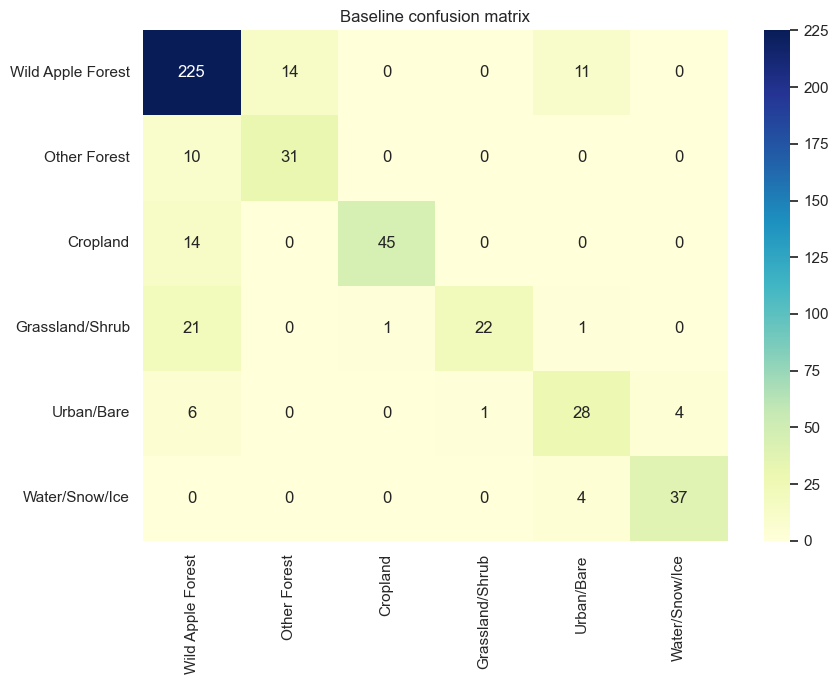

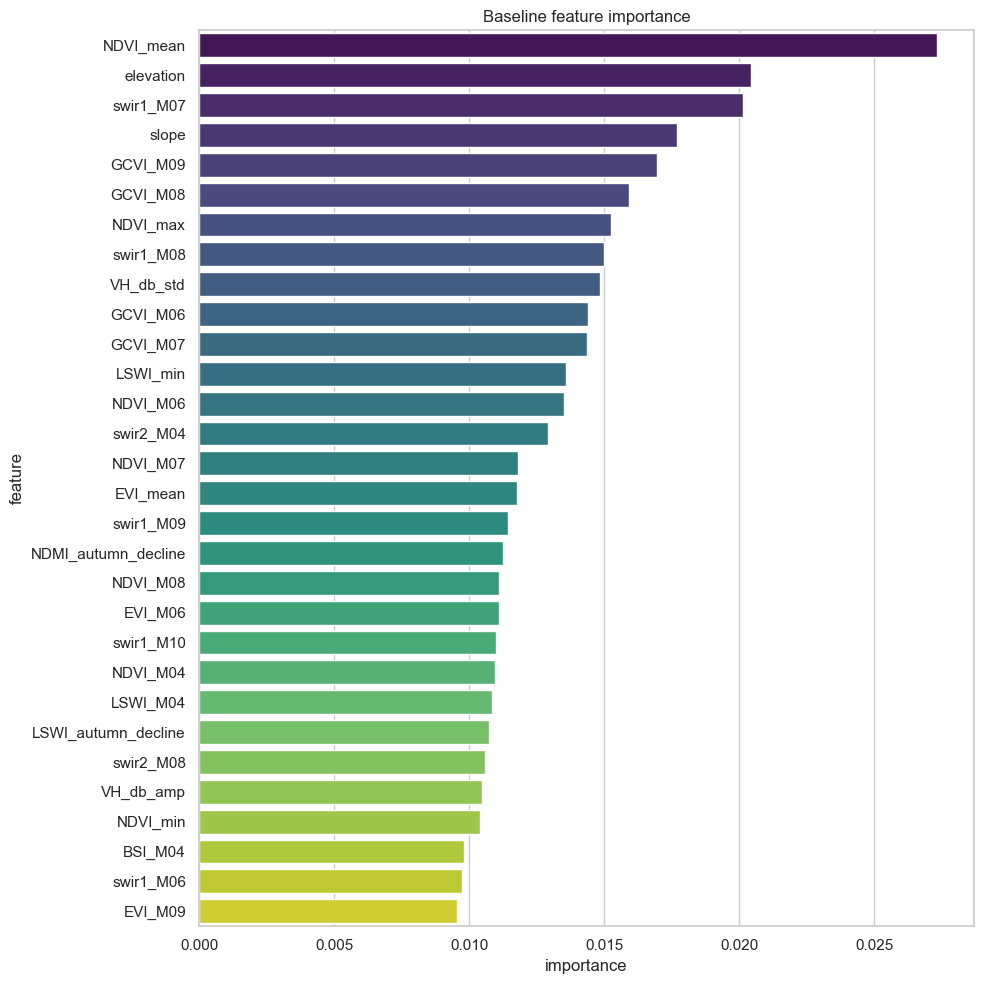

,feature,importance
0,NDVI_mean,0.027318
1,elevation,0.020447
2,swir1_M07,0.020150
3,slope,0.017677
4,GCVI_M09,0.016961
5,GCVI_M08,0.015897
6,NDVI_max,0.015249
7,swir1_M08,0.014976
8,VH_db_std,0.014855
9,GCVI_M06,0.014412


In [7]:
NON_FEATURE_COLUMNS = {"class", "source", "sample_id", "group_id", "system:index", ".geo"}


def prepare_baseline_table(df):
    df = df.copy()
    feature_cols = [col for col in df.columns if col not in NON_FEATURE_COLUMNS]
    numeric_features = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    valid_mask = df["class"].notna() & df["group_id"].notna()
    numeric_features = numeric_features.loc[valid_mask]
    target = df.loc[valid_mask, "class"].astype(int)
    groups = df.loc[valid_mask, "group_id"].astype(str)
    return numeric_features, target, groups, feature_cols


X, y, groups, feature_cols = prepare_baseline_table(df_raw)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols, index=X.index)

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=CONFIG["random_seed"])
train_idx, test_idx = next(gss.split(X_imputed, y, groups))

X_train = X_imputed.iloc[train_idx]
X_test = X_imputed.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=CONFIG["random_seed"],
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
oa = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Overall accuracy: {oa:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report_df.to_csv(OUTPUT_DIR / "baseline_classification_report.csv")

label_order = sorted(CLASS_INFO)
label_names = [CLASS_INFO[label] for label in label_order]
cm = confusion_matrix(y_test, y_pred, labels=label_order)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
cm_df.to_csv(OUTPUT_DIR / "baseline_confusion_matrix.csv")

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Baseline confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_confusion_matrix.png", dpi=200)
plt.show()

feature_importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance_df.to_csv(OUTPUT_DIR / "baseline_feature_importance.csv", index=False)

top_n = 30 if len(feature_importance_df) > 30 else len(feature_importance_df)
plt.figure(figsize=(10, 10))
sns.barplot(data=feature_importance_df.head(top_n), y="feature", x="importance", palette="viridis")
plt.title("Baseline feature importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_feature_importance.png", dpi=200)
plt.show()

feature_importance_df.head(20)
        


## 5. Helpers for the next stage: long time series table, cubic fit, and JM distance

These helpers are not fully wired into the baseline model yet.
They are included now so the notebook structure already matches the refactor plan.
        


In [8]:
def build_long_timeseries_table(df, prefixes=None):
    prefixes = prefixes or (OPTICAL_SERIES_PREFIXES + SAR_SERIES_PREFIXES)
    rows = []
    id_cols = ["class", "source", "sample_id", "group_id"]

    for prefix in prefixes:
        value_cols = [col for col in df.columns if col.startswith(f"{prefix}_M")]
        if not value_cols:
            continue
        melted = df[id_cols + value_cols].melt(
            id_vars=id_cols,
            value_vars=value_cols,
            var_name="band_month",
            value_name="value",
        )
        melted["feature_name"] = prefix
        melted["month"] = melted["band_month"].str.extract(r"M(\d{2})").astype(int)
        melted["time_offset"] = melted["month"] - CONFIG["start_month"]
        rows.append(melted)

    if not rows:
        return pd.DataFrame()

    long_df = pd.concat(rows, ignore_index=True)
    long_df["class_name"] = long_df["class"].map(CLASS_INFO)
    return long_df.sort_values(["feature_name", "group_id", "month"]).reset_index(drop=True)


def fit_cubic_series(group):
    x = group["time_offset"].to_numpy(dtype=float)
    y_values = pd.to_numeric(group["value"], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y_values)
    x = x[mask]
    y_values = y_values[mask]
    result = {
        "group_id": group["group_id"].iloc[0],
        "sample_id": group["sample_id"].iloc[0],
        "class": group["class"].iloc[0],
        "class_name": group["class_name"].iloc[0],
        "feature_name": group["feature_name"].iloc[0],
    }
    if len(x) < 4:
        result.update({"a3": np.nan, "a2": np.nan, "a1": np.nan, "a0": np.nan, "r2": np.nan})
        return result
    coeffs = np.polyfit(x, y_values, deg=3)
    pred = np.polyval(coeffs, x)
    ss_res = np.sum((y_values - pred) ** 2)
    ss_tot = np.sum((y_values - np.mean(y_values)) ** 2)
    result.update({
        "a3": coeffs[0],
        "a2": coeffs[1],
        "a1": coeffs[2],
        "a0": coeffs[3],
        "r2": np.nan if ss_tot == 0 else 1 - ss_res / ss_tot,
    })
    return result


def batch_fit_cubic(long_df):
    if long_df.empty:
        return pd.DataFrame()
    grouped = long_df.groupby(["feature_name", "group_id"], sort=False)
    return pd.DataFrame([fit_cubic_series(group) for _, group in grouped])


def jeffries_matusita_distance(x1, x2):
    x1 = pd.to_numeric(pd.Series(x1), errors="coerce").dropna().to_numpy(dtype=float)
    x2 = pd.to_numeric(pd.Series(x2), errors="coerce").dropna().to_numpy(dtype=float)
    if len(x1) < 2 or len(x2) < 2:
        return np.nan
    m1, m2 = np.mean(x1), np.mean(x2)
    v1, v2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    if v1 <= 0 or v2 <= 0:
        return np.nan
    bhattacharyya = ((m1 - m2) ** 2) / (4 * (v1 + v2)) + 0.5 * np.log((v1 + v2) / (2 * np.sqrt(v1 * v2)))
    return float(2 * (1 - np.exp(-bhattacharyya)))


LONG_DF = build_long_timeseries_table(df_raw)
FITTED_CUBIC_DF = batch_fit_cubic(LONG_DF)

LONG_DF.to_csv(OUTPUT_DIR / "monthly_long_table.csv", index=False)
FITTED_CUBIC_DF.to_csv(OUTPUT_DIR / "cubic_fit_table.csv", index=False)

print("Long monthly table:", LONG_DF.shape)
print("Cubic fit table:", FITTED_CUBIC_DF.shape)
FITTED_CUBIC_DF.head()
        


Long monthly table: (129408, 10)
Cubic fit table: (7144, 10)


,group_id,sample_id,class,class_name,feature_name,a3,a2,a1,a0,r2
0,wildapple_00000,wildapple_00000,1,Wild Apple Forest,EVI,-0.014339,0.114302,-0.090385,0.074689,0.940314
1,wildapple_00001,wildapple_00001,1,Wild Apple Forest,EVI,-0.002262,0.005603,0.088354,0.089012,0.824677
2,wildapple_00002,wildapple_00002,1,Wild Apple Forest,EVI,0.005318,-0.078136,0.310855,0.177026,0.724937
3,wildapple_00003,wildapple_00003,1,Wild Apple Forest,EVI,0.002219,-0.024456,0.060845,0.107050,0.848900
4,wildapple_00004,wildapple_00004,1,Wild Apple Forest,EVI,0.002219,-0.024456,0.060845,0.107050,0.848900


## 6. Area statistics helper for the later GEE classification image


In [9]:
def calculate_area_by_class(classified_image, roi, class_info):
    pixel_area = ee.Image.pixelArea().rename("area")
    features = []
    for class_id, class_name in class_info.items():
        class_mask = classified_image.eq(class_id)
        area_m2 = pixel_area.updateMask(class_mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=CONFIG["scale"],
            maxPixels=1e13,
        ).get("area")
        features.append(ee.Feature(None, {"class_id": class_id, "class_name": class_name, "area_m2": area_m2}))
    return ee.FeatureCollection(features)


# TODO in the next implementation step:
# 1. convert sklearn RF to a GEE classifier with geemap.ml
# 2. classify FEATURE_IMAGE in GEE
# 3. apply conservative smoothing and patch filtering
# 4. run calculate_area_by_class on the post-processed image
        


## 7. Next implementation checkpoints

Recommended next actions in this notebook:
1. replace the wild apple asset path and verify the baseline sample table
2. add sample cleaning rules and outlier filters
3. merge cubic-fit coefficients back into the modeling table
4. run Jeffries-Matusita + RF screening on candidate features
5. add SHAP global and local plots
6. back-write the selected RF into GEE and finish map smoothing + area reports
        
